ARTI308 - Machine Learning

# Lab 4 Assignment: Data Quality Assessment & Preprocessing

Razan Mohammed Alqarni

Dataset: Superstore Sales (train.xlsx), same one I used in Lab 2 and Lab 3.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_excel("train.xlsx")
print(df.shape)
df.head()

(9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-08-11 00:00:00,2017-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-08-11 00:00:00,2017-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-12-06 00:00:00,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-11-10 00:00:00,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-11-10 00:00:00,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


## Task 1: Identify data quality issues

In [3]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


Order Date and Ship Date are object, not datetime. I checked what is inside them:

In [4]:
print(df["Order Date"].apply(type).value_counts())
print(df["Ship Date"].apply(type).value_counts())

Order Date
<class 'str'>                  5841
<class 'datetime.datetime'>    3959
Name: count, dtype: int64
Ship Date
<class 'str'>                  5985
<class 'datetime.datetime'>    3815
Name: count, dtype: int64


In [5]:
df[["Order Date", "Ship Date"]].head()

,Order Date,Ship Date
0,2017-08-11 00:00:00,2017-11-11 00:00:00
1,2017-08-11 00:00:00,2017-11-11 00:00:00
2,2017-12-06 00:00:00,16/06/2017
3,2016-11-10 00:00:00,18/10/2016
4,2016-11-10 00:00:00,18/10/2016


The date columns have two types mixed together. Some values are text like 16/06/2017 (day first) and some are already datetime. I noticed the datetime ones look wrong: in row 0 the order date is 2017-08-11 but the ship date is 2017-11-11, which would be 3 months of shipping. It looks like Excel converted the dates where the day is 12 or less and swapped the day with the month, so 2017-08-11 is really 8 November 2017.

In [6]:
df.isna().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [7]:
df[df["Postal Code"].isna()][["City", "State", "Postal Code"]]

,City,State,Postal Code
2234,Burlington,Vermont,NaN
5274,Burlington,Vermont,NaN
8798,Burlington,Vermont,NaN
9146,Burlington,Vermont,NaN
9147,Burlington,Vermont,NaN
9148,Burlington,Vermont,NaN
9386,Burlington,Vermont,NaN
9387,Burlington,Vermont,NaN
9388,Burlington,Vermont,NaN
9389,Burlington,Vermont,NaN


In [8]:
print("Duplicated rows:", df.duplicated().sum())

Duplicated rows: 0


In [9]:
df["Sales"].describe()

,Sales
count,9800.000000
mean,230.769059
std,626.651875
min,0.444000
25%,17.248000
50%,54.490000
75%,210.605000
max,22638.480000


In [10]:
print("Skewness:", df["Sales"].skew())

Skewness: 12.983482865034619


**Issues I found:**

1. Order Date and Ship Date are stored as object with mixed formats, and in the converted ones the day and month are swapped.
2. Postal Code has 11 missing values. All of them are Burlington, Vermont.
3. Postal Code is float64 but it is a code, not a real number.
4. Sales is very skewed to the right. The mean is 230.77 but the median is only 54.49, and the max is 22638.48, so there are outliers.
5. No duplicated rows.
6. Row ID is just a counter, it is not useful as a feature.

### Fixing the dates
For the text values I parse them as day first. For the ones Excel already converted I swap the day and month back.

In [11]:
def fix_date(v):
    if isinstance(v, str):
        return pd.to_datetime(v, dayfirst=True)
    return pd.Timestamp(year=v.year, month=v.day, day=v.month)

df["Order Date"] = df["Order Date"].apply(fix_date)
df["Ship Date"] = df["Ship Date"].apply(fix_date)

df[["Order Date", "Ship Date"]].dtypes

,0
Order Date,datetime64[ns]
Ship Date,datetime64[ns]


To make sure the fix is correct I calculated the number of days between the order and the shipping.

In [12]:
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days
print("Min:", df["Shipping Days"].min())
print("Max:", df["Shipping Days"].max())
print("Negative values:", (df["Shipping Days"] < 0).sum())

Min: 0
Max: 7
Negative values: 0


All orders are shipped within 0 to 7 days and there are no negative values, so the dates are correct now. I will also keep Shipping Days as a second numerical feature for Task 4 and Task 5, because the dataset only has Sales as a real numerical column.

## Task 2: Missing values

In [13]:
print("Before:", df.shape)
df_clean = df.dropna().copy()
print("After:", df_clean.shape)

Before: (9800, 19)
After: (9789, 19)


In [14]:
df_clean["Postal Code"] = df_clean["Postal Code"].astype(int).astype(str).str.zfill(5)
df_clean.isna().sum().sum()

np.int64(0)

I chose **Strategy 1: Remove Records**.

Why:
- Only 11 rows out of 9800 are missing (about 0.11%), so removing them does not affect the dataset.
- Mean or median imputation does not make sense here because Postal Code is not a measurement. The average of postal codes would give a code for a place that does not exist.

I also changed Postal Code to text with 5 digits so it is not treated as a number.

## Task 3: Outliers using IQR

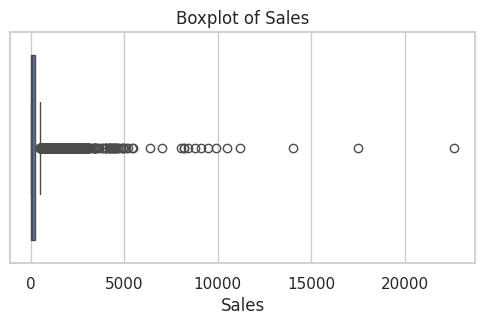

In [15]:
plt.figure(figsize=(6,3))
sns.boxplot(x=df_clean["Sales"])
plt.title("Boxplot of Sales")
plt.show()

In [16]:
Q1 = df_clean["Sales"].quantile(0.25)
Q3 = df_clean["Sales"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower limit:", lower)
print("Upper limit:", upper)

Q1: 17.248
Q3: 210.392
IQR: 193.144
Lower limit: -272.468
Upper limit: 500.108


In [17]:
outliers = df_clean[(df_clean["Sales"] < lower) | (df_clean["Sales"] > upper)]
print("Number of outliers:", outliers.shape[0])
print("Percentage:", outliers.shape[0] / df_clean.shape[0] * 100)

Number of outliers: 1141
Percentage: 11.655940341199306


In [18]:
outliers.sort_values("Sales", ascending=False)[["Category", "Sub-Category", "Product Name", "Sales"]].head(10)

,Category,Sub-Category,Product Name,Sales
2697,Technology,Machines,Cisco TelePresence System EX90 Videoconferenci...,22638.480
6826,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,17499.950
8153,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,13999.960
2623,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,11199.968
4190,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,10499.970
9039,Office Supplies,Binders,GBC Ibimaster 500 Manual ProClick Binding System,9892.740
4098,Office Supplies,Binders,Ibico EPK-21 Electric Binding System,9449.950
4277,Technology,Machines,"3D Systems Cube Printer, 2nd Generation, Magenta",9099.930
8488,Technology,Machines,HP Designjet T520 Inkjet Large Format Printer ...,8749.950
6425,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,8399.976


There are 1141 outliers, which is about 11.7% of the data. The lower limit is negative and sales cannot be negative, so all the outliers are high values. When I looked at the biggest ones they are expensive products like copiers and machines, so they are real sales and not mistakes.

Because of that I decided to **cap** the outliers instead of removing them. Removing would delete almost 12% of the data, which is a lot.

In [19]:
df_capped = df_clean.copy()
df_capped["Sales"] = df_capped["Sales"].clip(lower, upper)

print("Shape:", df_capped.shape)
print("Max Sales before:", df_clean["Sales"].max())
print("Max Sales after:", df_capped["Sales"].max())
print("Skewness before:", df_clean["Sales"].skew())
print("Skewness after:", df_capped["Sales"].skew())

Shape: (9789, 19)
Max Sales before: 22638.48
Max Sales after: 500.108
Skewness before: 13.053630955201138
Skewness after: 1.2183963129760327


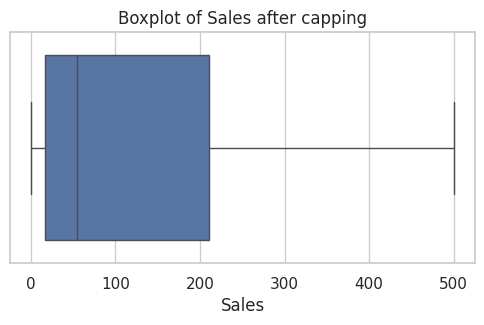

In [20]:
plt.figure(figsize=(6,3))
sns.boxplot(x=df_capped["Sales"])
plt.title("Boxplot of Sales after capping")
plt.show()

After capping, the number of rows is the same (9789) but the max is now 500.11 instead of 22638.48. The skewness went down from 13.05 to 1.22 and the boxplot has no points outside the whiskers.

## Task 4: Normalization
I used Sales and Shipping Days. I did not include Row ID and Postal Code because they are IDs.

In [21]:
df_capped[["Sales", "Shipping Days"]].describe()

,Sales,Shipping Days
count,9789.000000,9789.000000
mean,140.614676,3.961181
std,169.301036,1.750452
min,0.444000,0.000000
25%,17.248000,3.000000
50%,54.384000,4.000000
75%,210.392000,5.000000
max,500.108000,7.000000


### Min-Max

In [22]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = df_capped[["Sales", "Shipping Days"]].copy()
df_scaled[["Sales", "Shipping Days"]] = scaler.fit_transform(df_scaled)

df_scaled.head()

,Sales,Shipping Days
0,0.523384,0.428571
1,1.000000,0.428571
2,0.028371,0.571429
3,1.000000,1.000000
4,0.043877,1.000000


In [23]:
df_scaled.describe()

,Sales,Shipping Days
count,9789.000000,9789.000000
mean,0.280530,0.565883
std,0.338830,0.250065
min,0.000000,0.000000
25%,0.033631,0.428571
50%,0.107953,0.571429
75%,0.420178,0.714286
max,1.000000,1.000000


### Z-score

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_standardized = df_capped[["Sales", "Shipping Days"]].copy()
df_standardized[["Sales", "Shipping Days"]] = scaler.fit_transform(df_standardized)

df_standardized.head()

,Sales,Shipping Days
0,0.716780,-0.549132
1,2.123506,-0.549132
2,-0.744243,0.022178
3,2.123506,1.736108
4,-0.698476,1.736108


In [25]:
df_standardized.describe().round(3)

,Sales,Shipping Days
count,9789.000,9789.000
mean,0.000,0.000
std,1.000,1.000
min,-0.828,-2.263
25%,-0.729,-0.549
50%,-0.509,0.022
75%,0.412,0.593
max,2.124,1.736


Before scaling, Sales goes from 0.44 to 500 but Shipping Days only goes from 0 to 7, so in a model like KNN the Sales column would control the distance just because its numbers are bigger.

- After Min-Max both columns are between 0 and 1 (min = 0, max = 1).
- After Z-score both columns have mean 0 and std 1. Positive means above the average and negative means below it.

In both methods the order of the values stays the same, only the scale changes.

## Task 5: PCA

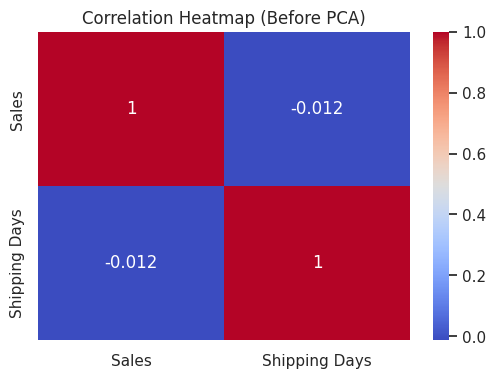

In [26]:
plt.figure(figsize=(6,4))
sns.heatmap(df_standardized.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Before PCA)")
plt.show()

In [27]:
from sklearn.decomposition import PCA

X = df_standardized[["Sales", "Shipping Days"]]

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.50586026 0.49413974]


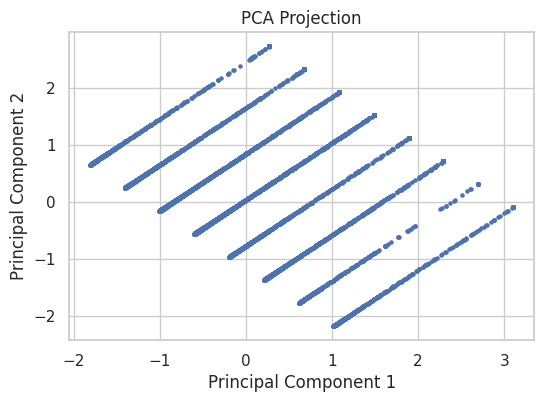

In [28]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1], s=5)
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

**Interpretation:**

The correlation between Sales and Shipping Days is about -0.01, so there is almost no linear relationship between them. The price of an order does not change how long the shipping takes.

PC1 explains about 50.6% of the variance and PC2 explains about 49.4%. They are almost equal, which means PC1 alone does not summarize the data. If I keep only PC1 I lose around half of the information, so PCA is not useful for reducing these two features and I would keep both of them.

This makes sense because PCA works best when the features are strongly correlated, and here they are not. The diagonal lines in the plot appear because Shipping Days has only 8 different values (0 to 7).